# Download and prepare `SW_IN` (2004-2025)

**notebook version**: `4` (16 Jul 2026)

## ℹ️ About this notebook

Downloads screened `SW_IN` from the InfluxDB database, merges the three data sources into one
continuous series, corrects a known logger timestamp shift, gap-fills the result and stores it
to the external data folder for use by notebook `11`.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra — nothing extra to set up. (Note that
diive's own `uv sync --group db` does not reach this project: dependency groups are local to the
project that declares them, so the extra is what crosses over.)

***

# Info about data sources

- `SW_IN`: NABEL (2004-2018), mst (2005-2021), diive (2022-2025)
- ETH data are the main data
- NABEL data are used to gap-fill ETH data to create a complete time series 2004-2018
- ETH data 2019-2025 is gap-filled separately, using only `SW_IN_POT`+
- Gap-filling is done using XGBoost, it also uses e.g. timestamp and potential radiation as features

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

# ⚙️ Settings

## Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "01_METEO_SW_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO"

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Last run: {dt_string}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-18 02:03:30
diive version: v0.91.0


In [3]:
# Result flags of SWINGapFillerXGBoost, see the class docstring.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = daytime gap, filled by the XGBoost model',
    2: '2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = daytime gap, filled by clearness-index interpolation',
}

## 🔌 Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

# ⬇️ `NABEL` data (2004-2018) and ETH data (2022-2025) from `diive` meteoscreening

## Download

In [5]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_swin_2004_2018_2022_2025, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1'] 
from measurements ['SW'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 5.91 s
Wall time: 8.71 s


In [6]:
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,0.0
2004-01-01 01:00:00,NaN,0.0
2004-01-01 01:30:00,NaN,0.0
2004-01-01 02:00:00,NaN,0.0
2004-01-01 02:30:00,NaN,0.0
...,...,...
2025-12-31 22:00:00,0.0,NaN
2025-12-31 22:30:00,0.0,NaN
2025-12-31 23:00:00,0.0,NaN


## Sanitize timestamp

In [7]:
nabel_eth_diive_swin_2004_2018_2022_2025 = TimestampSanitizer(
    data=nabel_eth_diive_swin_2004_2018_2022_2025,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


***

# ⬇️ Data from `mst` meteoscreening (2004-2021)

## Download

In [8]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_swin_2004_2021, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_T1_47_1'] from measurements ['SW'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 4.81 s
Wall time: 6.82 s


In [9]:
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_END,
2005-09-14 11:30:00,0.000000
2005-09-14 12:00:00,25.692612
2005-09-14 13:30:00,645.754150
2005-09-14 14:00:00,314.615936
2005-09-14 14:30:00,220.304276
...,...
2021-12-31 22:00:00,-9.935194
2021-12-31 22:30:00,-10.250348
2021-12-31 23:00:00,-9.810373


## Sanitize timestamp

In [10]:
mst_swin_2004_2021 = TimestampSanitizer(
    data=mst_swin_2004_2021,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 11:15:00,0.000000
2005-09-14 11:45:00,25.692612
2005-09-14 12:15:00,NaN
2005-09-14 12:45:00,NaN
2005-09-14 13:15:00,645.754150
...,...
2021-12-31 21:45:00,-9.935194
2021-12-31 22:15:00,-10.250348
2021-12-31 22:45:00,-9.810373


***

# ❇️ Merge data

ETH data from `diive` meteoscreening (2022-2025) are the main data, gaps before 2022 are
filled in from the `mst` meteoscreening.

In [11]:
# Merge data on index
swin_2004_2025 = nabel_eth_diive_swin_2004_2018_2022_2025.copy()
swin_2004_2025['SW_IN_T1_47_1'] = swin_2004_2025['SW_IN_T1_47_1'].combine_first(mst_swin_2004_2021['SW_IN_T1_47_1'])
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


## Sanitize timestamp

In [12]:
swin_2004_2025 = TimestampSanitizer(data=swin_2004_2025, output_middle_timestamp=True).get()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


## Heatmap

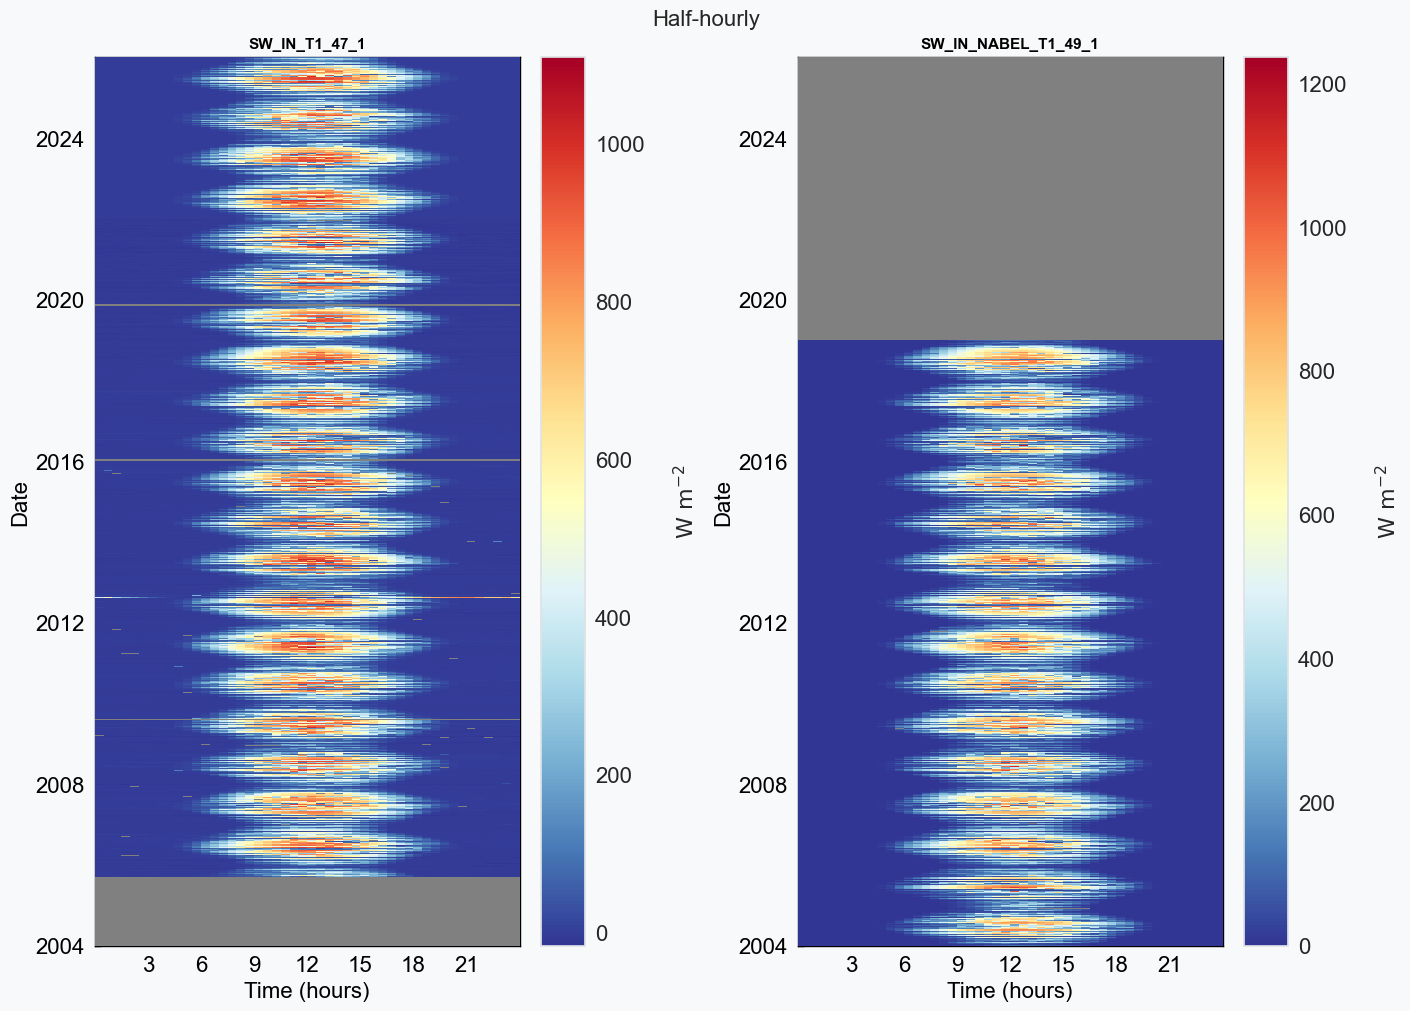

In [13]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1", title_fontsize=11))

***

# ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

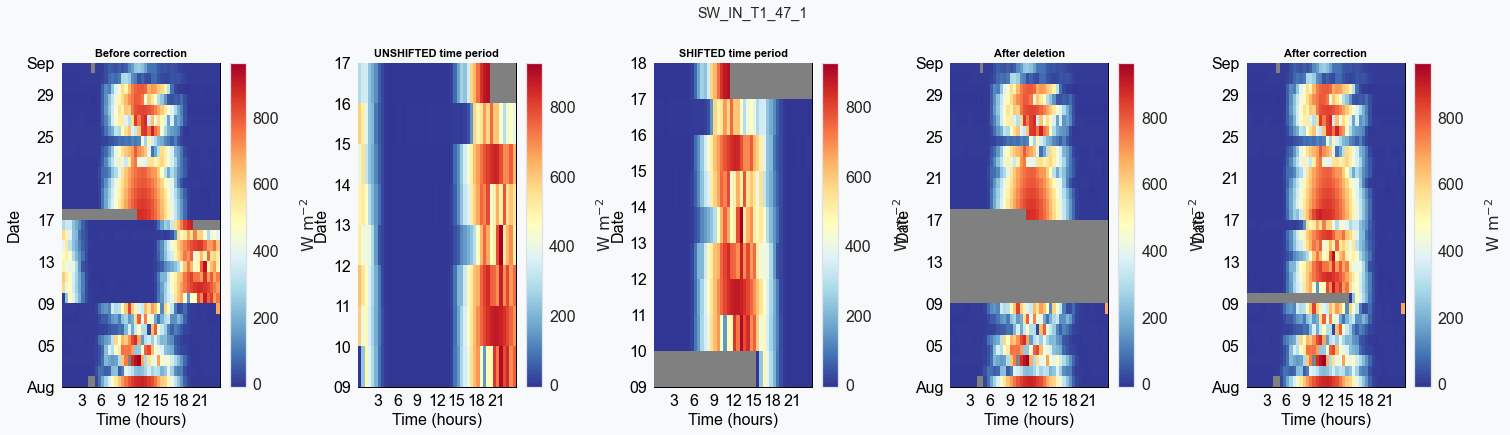

In [14]:
AFFECTED_VARS = ['SW_IN_T1_47_1']
_df = swin_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift SW_IN by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

In [15]:
swin_2004_2025 = _df.copy()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


::: {.callout-note title="Zero-offset correction"}
Version `3` of this notebook removed the `SW_IN` nighttime zero-offset here, with an explicit call
to `remove_radiation_zero_offset()`. That step is now done inside the gap-filler via
`correct_nighttime_offset=True` (see below), which applies the same correction
(`remove_nighttime_zero_offset()`) to each series before modelling. It is therefore no longer
done separately at this point.
:::

## Dataframe

In [16]:
display(swin_2004_2025)
swin_2004_2025.describe()

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
count,352940.000000,262774.000000
mean,141.793897,140.037811
std,239.442523,233.701783
min,-16.722927,0.000000
25%,-2.890419,0.000000
50%,1.288768,2.506354
75%,192.305201,186.456335
max,1109.351433,1236.721293


***

# 🟪 Prepare dataframes

Split into the two periods that are gap-filled separately: 2004-2018 (NABEL available as
driver) and 2019-2025 (no NABEL).

In [17]:
swin_2004_2018 = swin_2004_2025.loc[swin_2004_2025.index.year <= 2018].copy()
swin_2004_2018

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2018-12-31 21:45:00,-2.486487,0.0
2018-12-31 22:15:00,-2.620216,0.0
2018-12-31 22:45:00,-2.352738,0.0


In [18]:
swin_2019_2025 = swin_2004_2025.loc[swin_2004_2025.index.year >= 2019].copy()
swin_2019_2025 = swin_2019_2025.drop('SW_IN_NABEL_T1_49_1', axis=1)
swin_2019_2025

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2019-01-01 00:15:00,-2.149965
2019-01-01 00:45:00,-2.722333
2019-01-01 01:15:00,-3.087591
2019-01-01 01:45:00,-2.410228
2019-01-01 02:15:00,-2.400173
...,...
2025-12-31 21:45:00,0.000000
2025-12-31 22:15:00,0.000000
2025-12-31 22:45:00,0.000000


***

# 🟥 Gap-filling NABEL (2004-2018)

`SWINGapFillerXGBoost` calculates `SW_IN_POT` from `SITE_LAT`/`SITE_LON` itself, uses it to split
daytime from nighttime, sets nighttime gaps to zero and fills daytime gaps with XGBoost trained on
daytime observations only. `correct_nighttime_offset=True` removes the sensor's nighttime
zero-offset first, and negative values are clipped to zero internally
(`below_zero='zero'`) — no manual post-correction needed.

`interpolate_short_gaps=2` fills daytime gaps of up to 2 records (1 h at 30MIN resolution) by
interpolating the clearness index (`SW_IN`/`SW_IN_POT`) instead of using the model, and never
bridges a night. Short gaps are exactly the case the model cannot see, because the feature
engineer excludes the target from its own features.

## Run gap-filling

In [19]:
%%time

TARGET = "SW_IN_NABEL_T1_49_1"

gf_nabel = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2004_2018[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    correct_nighttime_offset=True,  # replaces the manual remove_radiation_zero_offset() step
    interpolate_short_gaps=2,  # fill daytime gaps <= 1h by clearness-index interpolation
    reduce_features=False,
    verbose=1,
    # XGBoost hyperparameters
    n_estimators=3000,
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1,
)
gf_nabel.run()

───────────────────────────── SW_IN Gap-Filling (SW_IN_NABEL_T1_49_1) ──────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (2.1s)

Output()

...

> Step 6: Training XGBoost on 137143 daytime records (incl. SHAP importances) (94.2s)

Output()

> Step 7: Filling daytime gaps (SHAP importances over full record) (338.1s)

v Done in 439.4s - 218 records filled (218 gaps total)

CPU times: total: 55min 20s
Wall time: 7min 19s


## Report

In [20]:
gf_nabel.report()

────────────────────────── SW_IN Gap-Filling Report: SW_IN_NABEL_T1_49_1 ───────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     False
  features_lag               []
  features_rolling           [4, 8, 24, 48]  (context drivers only)
  features_rolling_stats     ['median']
  features_ema               [6, 24]  (context drivers only)
  add_record_number          True
  context drivers            none

──────────────────────────────────────── Data & Performance ────────────────────────────────────────

...

MSE      4706.0906

RMSE     68.6010

MAPE     1577911597422911.2500

MAXE     748.4538

R2       0.9330

## Results: scores and feature importances

In [ ]:
r = gf_nabel.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

In [ ]:
r.feature_importances

## Add gap-filled series to dataframe

The gap-filler returns the series under its original name, so it is renamed to the `_gfXG`
convention used by the downstream notebooks.

In [ ]:
gapfilled_nabel = gf_nabel.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2004_2018[gapfilled_nabel.name] = gapfilled_nabel
swin_2004_2018[[TARGET, gapfilled_nabel.name]].describe()

## Plot time series

In [ ]:
swin_2004_2018[[TARGET, gapfilled_nabel.name]].plot(subplots=True, x_compat=True);

***

# 🟥 Gap-filling ETH (2004-2018) using NABEL+
- NABEL is now complete (no gaps) 2004-2018 and can be used as feature in those years

## Run gap-filling

The gap-filled NABEL series is passed in as an additional driver via `context_df`; `SW_IN_POT`
and the timestamp features are added by the gap-filler itself.

In [ ]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2004_2018 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2004_2018[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    context_df=swin_2004_2018[['SW_IN_NABEL_T1_49_1_gfXG']],  # NABEL as additional driver
    correct_nighttime_offset=True,
    interpolate_short_gaps=2,  # fill daytime gaps <= 1h by clearness-index interpolation
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters
    n_estimators=3000,
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1,
)
gf_eth_2004_2018.run()

## Report

In [ ]:
gf_eth_2004_2018.report()

## Results: scores and feature importances

In [ ]:
r = gf_eth_2004_2018.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

In [ ]:
r.feature_importances

## Add gap-filled series to dataframe

In [ ]:
gapfilled_eth_2004_2018 = gf_eth_2004_2018.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2004_2018[gapfilled_eth_2004_2018.name] = gapfilled_eth_2004_2018
swin_2004_2018[[TARGET, gapfilled_eth_2004_2018.name]].describe()

## Dataframe

In [ ]:
display(swin_2004_2018)
swin_2004_2018.describe()

***

# 🟥 Plots (2004-2018)

## Heatmap

In [ ]:
fig, axs = plt.subplots(ncols=4, figsize=(16, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_T1_47_1_gfXG']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1_gfXG", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_NABEL_T1_49_1']).plot(
    ax=axs[2], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_NABEL_T1_49_1_gfXG']).plot(
    ax=axs[3], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1_gfXG", title_fontsize=11))

## Time series plot

In [ ]:
swin_2004_2018.plot(subplots=True, x_compat=True);

***

# 🟧 Gap-filling ETH (2019-2025)
- From mst (2019-2021) and diive meteoscreening (2022-2025)
- No NABEL data in this period, so only `SW_IN_POT`+ timestamp features are used

## Run gap-filling

In [ ]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2019_2025 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2019_2025[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    correct_nighttime_offset=True,
    interpolate_short_gaps=2,  # fill daytime gaps <= 1h by clearness-index interpolation
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters
    n_estimators=3000,
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1,
)
gf_eth_2019_2025.run()

## Report

In [ ]:
gf_eth_2019_2025.report()

## Results: scores and feature importances

In [ ]:
r = gf_eth_2019_2025.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

In [ ]:
r.feature_importances

## Add gap-filled series to dataframe

In [ ]:
gapfilled_eth_2019_2025 = gf_eth_2019_2025.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2019_2025[gapfilled_eth_2019_2025.name] = gapfilled_eth_2019_2025
swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].describe()

## Plot time series

In [ ]:
swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].plot(subplots=True, x_compat=True);

## Dataframe

In [ ]:
display(swin_2019_2025)
swin_2019_2025.describe()

***

# ➡️ Prepare dataframe for export

In [ ]:
export_df = pd.concat([swin_2004_2018, swin_2019_2025], axis=0)
export_df = export_df[['SW_IN_T1_47_1_gfXG']].copy()
export_df

Sanity check: the exported series must be complete (no gaps) and non-negative.

In [ ]:
print(f"Records:        {len(export_df)}")
print(f"Missing values: {export_df['SW_IN_T1_47_1_gfXG'].isnull().sum()}")
print(f"Negative values: {(export_df['SW_IN_T1_47_1_gfXG'] < 0).sum()}")
export_df.describe()

In [ ]:
fig, axs = plt.subplots(ncols=1, figsize=(4, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df['SW_IN_T1_47_1_gfXG']).plot(
    ax=axs, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1_gfXG", title_fontsize=11))

***

# 💾 Save to file

In [ ]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

***

# End of notebook.

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")